# Mismatch Rate vs. QBER — Cross-Key Summary

A per-key, per-fault-type, per-probability breakdown of how mismatch rate tracks QBER.
Useful as a sanity-check table and as raw material for a poster figure — this notebook
mostly organizes data you already validated in 21-23, viewed a different way (across your 5
real key pairs rather than one at a time).

Run `20_data_cleaning_and_integrity.ipynb` first.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
from qne.cascade.validation_utils import wilson_ci

RESULTS = PROJECT_DIR / "results"
fault_data = {
    "toeplitz":       (pd.read_csv(str(RESULTS / "toeplitz_clean.csv")), "prob"),
    "final_key":      (pd.read_csv(str(RESULTS / "final_key_clean.csv")), "prob"),
    "verify_digest":  (pd.read_csv(str(RESULTS / "verify_digest_clean.csv")), "prob"),
    "reconciliation": (pd.read_csv(str(RESULTS / "reconciliation_clean.csv")), "reconciliation_prob"),
}


In [2]:
rows = []
for fault_type, (df, prob_col) in fault_data.items():
    for prob in sorted(df[prob_col].unique()):
        sub = df[df[prob_col] == prob]
        for key_idx in sorted(sub["key_index"].unique()):
            key_sub = sub[sub["key_index"] == key_idx]
            rows.append({
                "fault_type": fault_type, "prob": prob, "key_index": key_idx,
                "qber": key_sub["qber"].iloc[0], "n_trials": len(key_sub),
                "mismatch_rate": (~key_sub["keys_match"].fillna(True)).mean(),
            })

summary_table = pd.DataFrame(rows).sort_values(["fault_type", "prob", "qber"])
summary_table


,fault_type,prob,key_index,qber,n_trials,mismatch_rate
43,final_key,0.001,3,0.002618,10,0.0
42,final_key,0.001,2,0.002674,9,0.0
44,final_key,0.001,4,0.005195,9,0.0
40,final_key,0.001,0,0.012821,10,0.0
41,final_key,0.001,1,0.015831,10,0.0
...,...,...,...,...,...,...
118,verify_digest,0.500,3,0.002618,10,0.0
117,verify_digest,0.500,2,0.002674,9,0.0
119,verify_digest,0.500,4,0.005195,9,0.0
115,verify_digest,0.500,0,0.012821,10,0.0


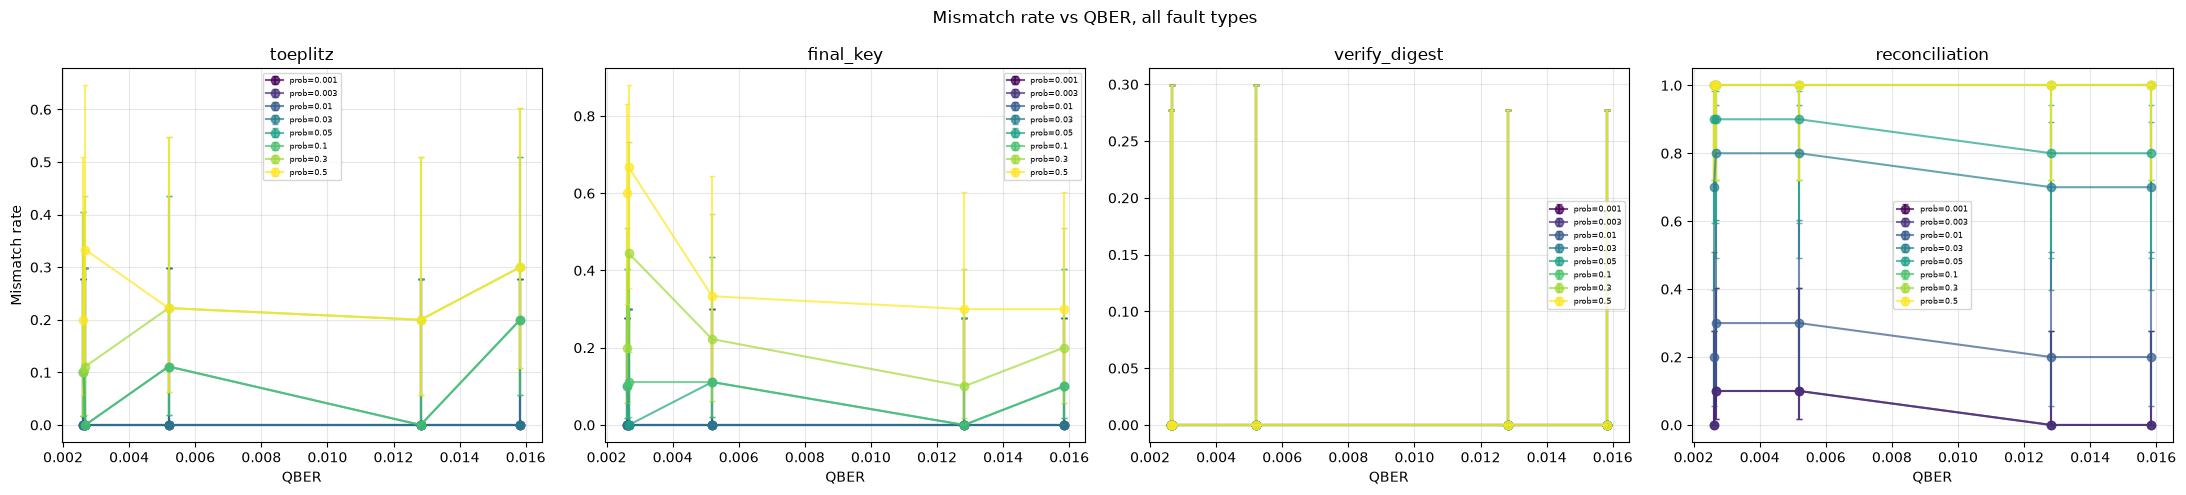

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (fault_type, (df, prob_col)) in zip(axes, fault_data.items()):
    probs = sorted(df[prob_col].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(probs)))
    for prob, color in zip(probs, colors):
        sub = df[df[prob_col] == prob]
        per_key_rows = []
        for key_idx in sorted(sub["key_index"].unique()):
            key_sub = sub[sub["key_index"] == key_idx]
            p_hat, lo, hi = wilson_ci((~key_sub["keys_match"].fillna(True)).sum(), len(key_sub))
            per_key_rows.append({"qber": key_sub["qber"].iloc[0], "mean": p_hat, "lo": lo, "hi": hi})
        per_key = pd.DataFrame(per_key_rows).sort_values("qber")
        ax.errorbar(per_key["qber"], per_key["mean"],
                      yerr=[np.clip(per_key["mean"]-per_key["lo"],0,None), np.clip(per_key["hi"]-per_key["mean"],0,None)],
                      fmt="o-", color=color, label=f"prob={prob}", alpha=0.7, capsize=2)
    ax.set_title(fault_type); ax.set_xlabel("QBER"); ax.legend(fontsize=6); ax.grid(alpha=0.3)
axes[0].set_ylabel("Mismatch rate")
plt.suptitle("Mismatch rate vs QBER, all fault types")
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_mismatch_vs_qber_all_faults.png"), dpi=150)
plt.show()
